Partie 6: Classement par le modèle Bradley-Terry 

Read data

In [ ]:
import pandas as pd
import pyarrow.parquet as pq

df_votes = pq.read_table("./data/votes.parquet").to_pandas()
print(" Votes dataset loaded successfully.")


print("Possible categories:")
print(df_votes["selected_category"].dropna().unique())

 Votes dataset loaded successfully.
Possible categories:
<ArrowStringArray>
[           'iasummit',        'explanations',             'stories',
      'administrative',             'recipes',               'ideas',
               'coach',           'languages',            'unguided',
          'expression',     'recommendations',             'langues',
            'regional', 'vie-professionnelle',           'summaries',
             'loisirs',            'conseils',       'administratif',
               'slang']
Length: 19, dtype: str


## 6.1 Construction de la matrice de gains W

In [17]:
import numpy as np


def build_W(df: pd.DataFrame, creativity_only: bool = False, min_comparisons: int = 30):
    # 1) On retire les ex-aequo pour Bradley-Terry de base
    mask_non_tie = ~df["both_equal"].fillna(False).astype(bool)
    d = df.loc[mask_non_tie].copy()

    # 2) Option: on garde seulement les conversations creativity
    if creativity_only:
        mask_creative = (
            d["conv_creative_a"].fillna(False).astype(bool)
            | d["conv_creative_b"].fillna(False).astype(bool)
        )
        d = d.loc[mask_creative].copy()

    # 3) Filtre: garder les modèles avec au moins N comparaisons
    counts = pd.concat([d["model_a_name"], d["model_b_name"]], ignore_index=True).value_counts()
    eligible = counts[counts >= min_comparisons].index
    d = d[d["model_a_name"].isin(eligible) & d["model_b_name"].isin(eligible)].copy()

    # 4) Liste des modèles + index
    models = sorted(set(d["model_a_name"]).union(set(d["model_b_name"])))
    idx = {m: i for i, m in enumerate(models)}

    # 5) Matrice de gains W[i,j] = nb fois i préféré à j
    W = np.zeros((len(models), len(models)), dtype=int)

    for _, row in d.iterrows():
        a = row["model_a_name"]
        b = row["model_b_name"]
        winner = row["chosen_model_name"]

        if winner == a:
            W[idx[a], idx[b]] += 1
        elif winner == b:
            W[idx[b], idx[a]] += 1
        # sinon: vote invalide -> ignoré

    W_df = pd.DataFrame(W, index=models, columns=models)
    return W_df, d


MIN_COMPARISONS = 30

# Matrice globale (hors ex-aequo + filtre N)
W_global, votes_used_global = build_W(
    df_votes,
    creativity_only=False,
    min_comparisons=MIN_COMPARISONS,
)
print(
    "W globale:",
    W_global.shape,
    "| votes utilisés:",
    len(votes_used_global),
    "| N =",
    MIN_COMPARISONS,
)
display(W_global.iloc[:10, :10])

# Matrice créativité (hors ex-aequo + filtre créativité + filtre N)
W_creative, votes_used_creative = build_W(
    df_votes,
    creativity_only=True,
    min_comparisons=MIN_COMPARISONS,
)
print(
    "W créativité:",
    W_creative.shape,
    "| votes utilisés:",
    len(votes_used_creative),
    "| N =",
    MIN_COMPARISONS,
)
display(W_creative.iloc[:10, :10])

W globale: (105, 105) | votes utilisés: 108545 | N = 30


,Apertus-70B-Instruct-2509,Apertus-8B-Instruct-2509,DeepSeek-V3.2,EuroLLM-22B-Instruct-2512,Qwen3-Coder-480B-A35B-Instruct,Yi-1.5-9B-Chat,aya-expanse-32b,aya-expanse-8b,c4ai-command-r-08-2024,chocolatine-14b-instruct-dpo-v1.2-q4
Apertus-70B-Instruct-2509,0,0,5,0,2,0,10,0,0,0
Apertus-8B-Instruct-2509,0,0,0,0,0,0,1,0,0,0
DeepSeek-V3.2,14,0,0,9,10,0,0,0,0,0
EuroLLM-22B-Instruct-2512,2,0,7,0,4,0,0,0,0,0
Qwen3-Coder-480B-A35B-Instruct,5,0,10,5,0,0,12,0,0,0
Yi-1.5-9B-Chat,0,0,0,0,0,0,0,0,0,0
aya-expanse-32b,7,1,0,0,2,0,0,0,32,0
aya-expanse-8b,0,0,0,0,0,0,0,0,5,0
c4ai-command-r-08-2024,0,0,0,0,0,3,18,4,2,0
chocolatine-14b-instruct-dpo-v1.2-q4,0,0,0,0,0,0,0,0,0,0


W créativité: (85, 85) | votes utilisés: 8972 | N = 30


,Apertus-70B-Instruct-2509,DeepSeek-V3.2,EuroLLM-22B-Instruct-2512,Qwen3-Coder-480B-A35B-Instruct,aya-expanse-32b,aya-expanse-8b,c4ai-command-r-08-2024,chocolatine-14b-instruct-dpo-v1.2-q4,chocolatine-2-14b-instruct-v2.0.3-q8,claude-3-5-sonnet-v2
Apertus-70B-Instruct-2509,0,1,0,0,0,0,0,0,0,0
DeepSeek-V3.2,3,0,0,0,0,0,0,0,0,0
EuroLLM-22B-Instruct-2512,0,0,0,1,0,0,0,0,0,0
Qwen3-Coder-480B-A35B-Instruct,0,1,1,0,0,0,0,0,0,0
aya-expanse-32b,0,0,0,0,0,0,1,0,0,0
aya-expanse-8b,0,0,0,0,0,0,1,0,0,0
c4ai-command-r-08-2024,0,0,0,0,0,0,0,0,0,2
chocolatine-14b-instruct-dpo-v1.2-q4,0,0,0,0,0,0,0,0,0,0
chocolatine-2-14b-instruct-v2.0.3-q8,0,0,0,0,0,0,0,0,0,1
claude-3-5-sonnet-v2,0,0,0,0,0,2,5,0,5,0


### Sensibilite au seuil N (comparaison de plusieurs valeurs)

Comparaison de couverture selon N


,N,models_global,votes_global,models_creativity,votes_creativity
0,10,105,108545,98,9223
1,20,105,108545,95,9177
2,30,105,108545,85,8972
3,50,104,108511,79,8747
4,80,103,108435,72,8298


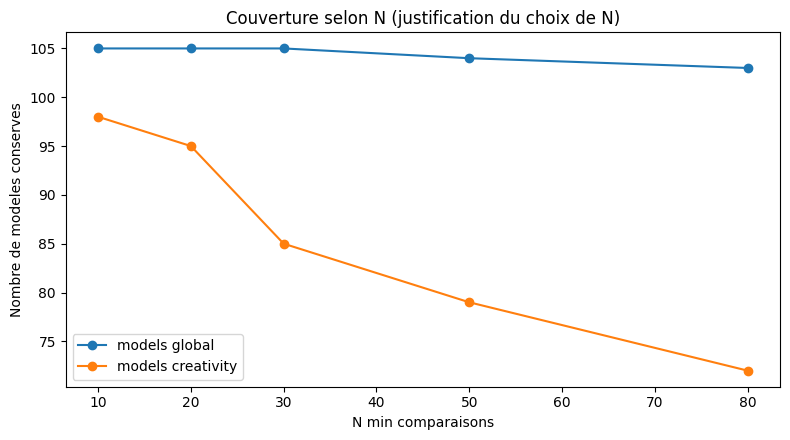

In [18]:
import matplotlib.pyplot as plt

N_values = [10, 20, 30, 50, 80]
results = []

for N in N_values:
    Wg, dg = build_W(df_votes, creativity_only=False, min_comparisons=N)
    Wc, dc = build_W(df_votes, creativity_only=True, min_comparisons=N)

    results.append(
        {
            "N": N,
            "models_global": int(Wg.shape[0]),
            "votes_global": int(len(dg)),
            "models_creativity": int(Wc.shape[0]),
            "votes_creativity": int(len(dc)),
        }
    )

sens = pd.DataFrame(results).sort_values("N").reset_index(drop=True)
print("Comparaison de couverture selon N")
display(sens)

plt.figure(figsize=(8, 4.5))
plt.plot(sens["N"], sens["models_global"], marker="o", label="models global")
plt.plot(sens["N"], sens["models_creativity"], marker="o", label="models creativity")
plt.xlabel("N min comparaisons")
plt.ylabel("Nombre de modeles conserves")
plt.title("Couverture selon N (justification du choix de N)")
plt.legend()
plt.tight_layout()
plt.show()

### Justification du seuil N = 30

Compromis entre:

- **Stabilite statistique**: avec moins de comparaisons, les estimations Bradley-Terry deviennent tres sensibles au hasard d'echantillonnage.
- **Couverture des modeles**: un N trop eleve retirerait trop de modeles et reduirait la representativite.

En pratique ici (plus de 100 modeles, paires desequilibrees), **N = 30** conserve une bonne partie des modeles tout en limitant les estimations instables dues au faible nombre de duels.

## 6.2.1 Classement global vs classement créativité

Classement Bradley-Terry global (bt)


,model,beta,rank_bt
0,gemini-3.1-flash-lite-preview,0.029809,1.0
1,mistral-medium-3.1,0.022571,2.0
2,gpt-5.4,0.021448,3.0
3,mistral-large-2512,0.021443,4.0
4,mistral-medium-2508,0.021022,5.0
...,...,...,...
100,mixtral-8x22b-instruct-v0.1,0.002142,101.0
101,chocolatine-2-14b-instruct-v2.0.3-q8,0.001765,102.0
102,qwen2-7b-instruct,0.001733,103.0
103,Yi-1.5-9B-Chat,0.001729,104.0


Classement Bradley-Terry creativite (bt_creative)


,model,beta,rank_bt_creative
0,mistral-medium-2508,0.040228,1.0
1,qwen3-max-2025-09-23,0.031068,2.0
2,mistral-large-2512,0.030727,3.0
3,glm-4.5,0.029614,4.0
4,deepseek-chat-v3.1,0.026413,5.0
...,...,...,...
80,lfm-40b,0.002333,81.0
81,mistral-nemo-2407,0.001980,82.0
82,mixtral-8x22b-instruct-v0.1,0.001762,83.0
83,chocolatine-2-14b-instruct-v2.0.3-q8,0.001158,84.0


Spearman rho = 0.880 (p-value=1.47e-28, modeles communs: 85)

Top 10 qui montent en creativite:


,rank_global,rank_creative,delta_rank
gpt-5-nano,90.0,44.0,46.0
deepseek-r1-distill-llama-70b,89.0,45.0,44.0
qwen-3-8b,69.0,36.0,33.0
hermes-4-70b,86.0,54.0,32.0
qwq-32b,88.0,57.0,31.0
qwen3-30b-a3b,66.0,35.0,31.0
minimax-m2,71.0,40.0,31.0
deepseek-r1,48.0,18.0,30.0
qwen3-32b,53.0,23.0,30.0
glm-4.6,42.0,13.0,29.0


Top 10 qui descendent en creativite:


,rank_global,rank_creative,delta_rank
magistral-small-2506,39.0,68.0,-29.0
grok-3-mini-beta,24.0,51.0,-27.0
deepseek-v3-0324,14.0,24.0,-10.0
deepseek-v3-chat,17.0,26.0,-9.0
mistral-large-2411,50.0,59.0,-9.0
mistral-saba,51.0,60.0,-9.0
claude-3-7-sonnet,34.0,43.0,-9.0
aya-expanse-32b,65.0,73.0,-8.0
o4-mini,62.0,70.0,-8.0
gemma-3-12b,23.0,30.0,-7.0


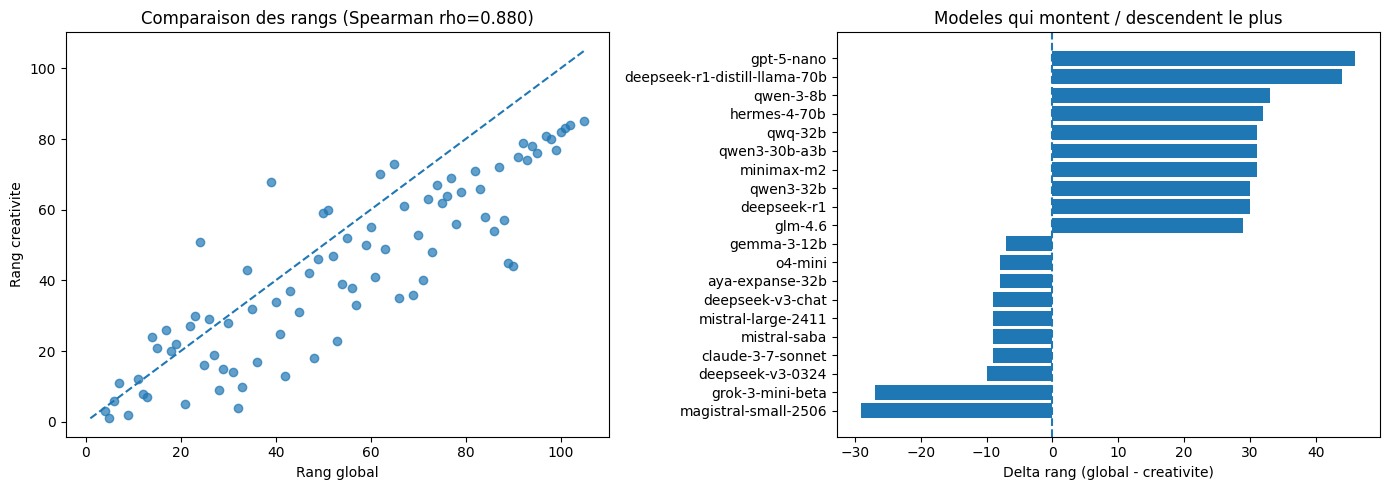

In [32]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import spearmanr


# Estimation Bradley-Terry par maximum de vraisemblance (ML) a partir de W
def fit_bt_from_W(W_df: pd.DataFrame):
    W = W_df.to_numpy(dtype=float)
    n = W.shape[0]
    eps = 1e-15

    if n == 0:
        return pd.Series(dtype=float, name="beta")
    if n == 1:
        return pd.Series([1.0], index=W_df.index, name="beta")

    def neg_loglik(theta_free: np.ndarray) -> float:
        theta = np.r_[theta_free, 0.0]
        beta = np.exp(theta)
        den = beta[:, None] + beta[None, :]

        # log L = sum_{i,j} W_ij * (theta_i - log(beta_i + beta_j))
        ll = np.sum(W * (theta[:, None] - np.log(den + eps)))
        return float(-ll)

    x0 = np.zeros(n - 1, dtype=float)
    res = minimize(neg_loglik, x0=x0, method="L-BFGS-B")

    theta_hat = np.r_[res.x, 0.0]
    beta_hat = np.exp(theta_hat - np.max(theta_hat))
    beta_hat = beta_hat / beta_hat.sum()

    return pd.Series(beta_hat, index=W_df.index, name="beta")


# 1) Deux classements Bradley-Terry
beta_global = fit_bt_from_W(W_global)
beta_creative = fit_bt_from_W(W_creative)

rank_global = beta_global.rank(ascending=False, method="min")
rank_creative = beta_creative.rank(ascending=False, method="min")

ranking_bt = pd.DataFrame(
    {
        "model": beta_global.index,
        "beta": beta_global.values,
        "rank_bt": rank_global.values,
    }
).sort_values(["rank_bt", "beta"], ascending=[True, False]).reset_index(drop=True)

ranking_bt_creative = pd.DataFrame(
    {
        "model": beta_creative.index,
        "beta": beta_creative.values,
        "rank_bt_creative": rank_creative.values,
    }
).sort_values(["rank_bt_creative", "beta"], ascending=[True, False]).reset_index(drop=True)

print("Classement Bradley-Terry global (bt)")
display(ranking_bt)

print("Classement Bradley-Terry creativite (bt_creative)")
display(ranking_bt_creative)

# 2) Comparaison sur les modeles communs
common_models = rank_global.index.intersection(rank_creative.index)
comp = pd.DataFrame(
    {
        "beta_global": beta_global.loc[common_models],
        "beta_creative": beta_creative.loc[common_models],
        "rank_global": rank_global.loc[common_models],
        "rank_creative": rank_creative.loc[common_models],
    }
)
comp["delta_rank"] = comp["rank_global"] - comp["rank_creative"]
# delta_rank > 0 => le modele monte en classement creativite

# Spearman avec scipy
rho, p_value = spearmanr(comp["rank_global"], comp["rank_creative"])
print(f"Spearman rho = {rho:.3f} (p-value={p_value:.2e}, modeles communs: {len(comp)})")

# 3) Modeles qui montent / descendent le plus
top_up = comp.sort_values("delta_rank", ascending=False).head(10)
top_down = comp.sort_values("delta_rank", ascending=True).head(10)

print("\nTop 10 qui montent en creativite:")
display(top_up[["rank_global", "rank_creative", "delta_rank"]])

print("Top 10 qui descendent en creativite:")
display(top_down[["rank_global", "rank_creative", "delta_rank"]])

# 4) Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Scatter des rangs global vs creativite
axes[0].scatter(comp["rank_global"], comp["rank_creative"], alpha=0.7)
max_rank = int(max(comp["rank_global"].max(), comp["rank_creative"].max()))
axes[0].plot([1, max_rank], [1, max_rank], linestyle="--")
axes[0].set_xlabel("Rang global")
axes[0].set_ylabel("Rang creativite")
axes[0].set_title(f"Comparaison des rangs (Spearman rho={rho:.3f})")

# (b) Barres des plus gros ecarts
movers = pd.concat([top_up, top_down]).sort_values("delta_rank")
axes[1].barh(movers.index, movers["delta_rank"])
axes[1].axvline(0, linestyle="--")
axes[1].set_xlabel("Delta rang (global - creativite)")
axes[1].set_title("Modeles qui montent / descendent le plus")

plt.tight_layout()
plt.show()

## 6.2.2 Transitivité stochastique et ex-aequo

In [20]:
from scipy.stats import norm
from scipy.optimize import minimize

# Utilise le meme N que plus haut
N_MIN = MIN_COMPARISONS if "MIN_COMPARISONS" in globals() else 30

# 0) Preparation des donnees (avec ex-aequo, sans perdre les infos de pair)
df_all = df_votes.dropna(subset=["model_a_name", "model_b_name"]).copy()
df_non_tie = df_all[~df_all["both_equal"].fillna(False).astype(bool)].copy()

# Filtre des modeles avec au moins N comparaisons (hors ex-aequo)
counts_non_tie = pd.concat(
    [df_non_tie["model_a_name"], df_non_tie["model_b_name"]],
    ignore_index=True,
).value_counts()
eligible_models = set(counts_non_tie[counts_non_tie >= N_MIN].index)

df_f = df_all[
    df_all["model_a_name"].isin(eligible_models)
    & df_all["model_b_name"].isin(eligible_models)
].copy()

models = sorted(set(df_f["model_a_name"]).union(set(df_f["model_b_name"])))
idx = {m: i for i, m in enumerate(models)}
n = len(models)

# 1) Matrices wins et ties (ties stockes une seule fois pour i<j)
W = np.zeros((n, n), dtype=float)
T_upper = np.zeros((n, n), dtype=float)

for _, r in df_f.iterrows():
    a = r["model_a_name"]
    b = r["model_b_name"]
    ia = idx[a]
    ib = idx[b]

    if bool(r["both_equal"]):
        i, j = (ia, ib) if ia < ib else (ib, ia)
        T_upper[i, j] += 1
    else:
        w = r["chosen_model_name"]
        if w == a:
            W[ia, ib] += 1
        elif w == b:
            W[ib, ia] += 1

W_df_all = pd.DataFrame(W, index=models, columns=models)

# 2) Transitivite stochastique (top 20 modeles les plus compares)
most_compared_20 = counts_non_tie[counts_non_tie.index.isin(models)].head(20).index.tolist()

beta_all = fit_bt_from_W(W_df_all)
order_20 = beta_all.loc[most_compared_20].sort_values(ascending=False).index.tolist()

viol_weak = 0
viol_strong = 0
total_triplets = 0

for a_i in range(len(order_20)):
    for b_i in range(a_i + 1, len(order_20)):
        for c_i in range(b_i + 1, len(order_20)):
            i = idx[order_20[a_i]]
            j = idx[order_20[b_i]]
            k = idx[order_20[c_i]]

            nij = W[i, j] + W[j, i]
            njk = W[j, k] + W[k, j]
            nik = W[i, k] + W[k, i]

            if nij == 0 or njk == 0 or nik == 0:
                continue

            pij = W[i, j] / nij
            pjk = W[j, k] / njk
            pik = W[i, k] / nik

            total_triplets += 1

            if (pij >= 0.5) and (pjk >= 0.5) and (pik < 0.5):
                viol_weak += 1

            if pik < max(pij, pjk):
                viol_strong += 1

weak_rate = (viol_weak / total_triplets) if total_triplets > 0 else np.nan
strong_rate = (viol_strong / total_triplets) if total_triplets > 0 else np.nan

print("=== Transitivite stochastique (top 20 plus compares) ===")
print(f"Triplets testes: {total_triplets}")
print(f"Violations weak ST: {viol_weak} ({weak_rate:.2%})")
print(f"Violations strong ST: {viol_strong} ({strong_rate:.2%})")

# 3) Taille minimale d'echantillon pour distinguer rang 3 vs rang 5
rank_all = beta_all.sort_values(ascending=False)
m3 = rank_all.index[2]
m5 = rank_all.index[4]

beta3 = rank_all.iloc[2]
beta5 = rank_all.iloc[4]
p_alt = float(beta3 / (beta3 + beta5))
p0 = 0.5

alpha = 0.05
power = 0.80
z_alpha_2 = norm.ppf(1 - alpha / 2)
z_power = norm.ppf(power)

if abs(p_alt - p0) < 1e-12:
    n_min = np.inf
else:
    n_min = ((z_alpha_2 * np.sqrt(p0 * (1 - p0)) + z_power * np.sqrt(p_alt * (1 - p_alt))) ** 2) / ((p_alt - p0) ** 2)
    n_min = int(np.ceil(n_min))

print("\n=== Puissance (80%) pour distinguer rang 3 vs rang 5 ===")
print(f"Rang 3: {m3} | beta={beta3:.6f}")
print(f"Rang 5: {m5} | beta={beta5:.6f}")
print(f"p_alt = P(rang3 bat rang5) = {p_alt:.4f}")
print(f"Comparaisons minimales (duels 3 vs 5) a alpha=0.05, power=0.80: {n_min}")

# 4) Davidson
pair_i = []
pair_j = []
w_ij = []
w_ji = []
t_ij = []

for i in range(n):
    for j in range(i + 1, n):
        wi = W[i, j]
        wj = W[j, i]
        tt = T_upper[i, j]
        if wi + wj + tt > 0:
            pair_i.append(i)
            pair_j.append(j)
            w_ij.append(wi)
            w_ji.append(wj)
            t_ij.append(tt)

pair_i = np.array(pair_i, dtype=int)
pair_j = np.array(pair_j, dtype=int)
w_ij = np.array(w_ij, dtype=float)
w_ji = np.array(w_ji, dtype=float)
t_ij = np.array(t_ij, dtype=float)
n_ij = w_ij + w_ji + t_ij

def davidson_nll(params: np.ndarray) -> float:
    # params = [theta_1..theta_{n-1}, eta], avec theta_n=0
    theta_free = params[:-1]
    eta = np.clip(params[-1], -20.0, 20.0)
    theta = np.r_[theta_free, 0.0]
    theta = np.clip(theta, -20.0, 20.0)

    beta = np.exp(theta)
    nu = np.exp(eta)

    bi = beta[pair_i]
    bj = beta[pair_j]
    s = np.sqrt(bi * bj)
    den = bi + bj + 2.0 * nu * s

    eps = 1e-15
    ll = np.sum(
        w_ij * np.log(bi + eps)
        + w_ji * np.log(bj + eps)
        + t_ij * (np.log(2.0 * nu + eps) + 0.5 * (np.log(bi + eps) + np.log(bj + eps)))
        - n_ij * np.log(den + eps)
    )
    return float(-ll)

x0 = np.zeros(n, dtype=float)
x0[-1] = np.log(0.2)
res_d = minimize(davidson_nll, x0=x0, method="L-BFGS-B")

theta_hat = np.r_[res_d.x[:-1], 0.0]
theta_hat = np.clip(theta_hat, -20.0, 20.0)
beta_d = np.exp(theta_hat - np.max(theta_hat))
beta_d = beta_d / beta_d.sum()
nu_davidson = float(np.exp(np.clip(res_d.x[-1], -20.0, 20.0)))
ll_davidson = float(-res_d.fun)

beta_davidson = pd.Series(beta_d, index=models, name="beta_davidson")
beta_bt_same_models = fit_bt_from_W(W_df_all).rename("beta_bt")

compare_bt_d = pd.concat([beta_bt_same_models, beta_davidson], axis=1)
compare_bt_d["rank_bt"] = compare_bt_d["beta_bt"].rank(ascending=False, method="min")
compare_bt_d["rank_davidson"] = compare_bt_d["beta_davidson"].rank(ascending=False, method="min")
compare_bt_d["delta_rank_davidson_minus_bt"] = compare_bt_d["rank_bt"] - compare_bt_d["rank_davidson"]
compare_bt_d = compare_bt_d.sort_values("beta_davidson", ascending=False)

print("\n=== Davidson (avec ex-aequo) vs Bradley-Terry ===")
print(f"nu (propension aux ex-aequo) estime = {nu_davidson:.4f}")
print(f"Log-vraisemblance Davidson (relative): {ll_davidson:.2f}")
print(f"Convergence optimizeur: {res_d.success}")

print("\nTop 10 Davidson:")
display(compare_bt_d.head(10)[["beta_bt", "beta_davidson", "rank_bt", "rank_davidson", "delta_rank_davidson_minus_bt"]])

print("Top 10 plus fortes hausses de rang avec Davidson:")
display(compare_bt_d.sort_values("delta_rank_davidson_minus_bt", ascending=False).head(10)[["rank_bt", "rank_davidson", "delta_rank_davidson_minus_bt"]])

print("Top 10 plus fortes baisses de rang avec Davidson:")
display(compare_bt_d.sort_values("delta_rank_davidson_minus_bt", ascending=True).head(10)[["rank_bt", "rank_davidson", "delta_rank_davidson_minus_bt"]])

=== Transitivite stochastique (top 20 plus compares) ===
Triplets testes: 960
Violations weak ST: 9 (0.94%)
Violations strong ST: 304 (31.67%)

=== Puissance (80%) pour distinguer rang 3 vs rang 5 ===
Rang 3: gpt-5.4 | beta=0.021448
Rang 5: mistral-medium-2508 | beta=0.021022
p_alt = P(rang3 bat rang5) = 0.5050
Comparaisons minimales (duels 3 vs 5) a alpha=0.05, power=0.80: 78252

=== Davidson (avec ex-aequo) vs Bradley-Terry ===
nu (propension aux ex-aequo) estime = 0.4876
Log-vraisemblance Davidson (relative): -162389.36
Convergence optimizeur: True

Top 10 Davidson:


,beta_bt,beta_davidson,rank_bt,rank_davidson,delta_rank_davidson_minus_bt
gemini-3.1-flash-lite-preview,0.029809,0.026180,1.0,1.0,0.0
mistral-medium-3.1,0.022571,0.021488,2.0,2.0,0.0
mistral-large-2512,0.021443,0.020744,4.0,3.0,1.0
gemini-3-flash-preview,0.020801,0.020687,6.0,4.0,2.0
mistral-medium-2508,0.021022,0.020479,5.0,5.0,0.0
gpt-5.4,0.021448,0.019898,3.0,6.0,-3.0
gemini-2.5-flash,0.020106,0.019821,7.0,7.0,0.0
gemini-2.0-flash,0.016710,0.017459,11.0,8.0,3.0
magistral-medium,0.017732,0.017433,8.0,9.0,-1.0
qwen3-max-2025-09-23,0.017595,0.017248,9.0,10.0,-1.0


Top 10 plus fortes hausses de rang avec Davidson:


,rank_bt,rank_davidson,delta_rank_davidson_minus_bt
gemma-2-27b-it-q8,61.0,53.0,8.0
gemini-1.5-pro,49.0,45.0,4.0
trinity-large-preview,64.0,60.0,4.0
glm-4.6,42.0,38.0,4.0
gemini-2.0-flash,11.0,8.0,3.0
llama-3.1-nemotron-70b-instruct,40.0,37.0,3.0
qwen2.5-32b-instruct,85.0,82.0,3.0
deepseek-r1-distill-llama-70b,89.0,87.0,2.0
qwen3-30b-a3b,66.0,64.0,2.0
gemma-3-4b,43.0,41.0,2.0


Top 10 plus fortes baisses de rang avec Davidson:


,rank_bt,rank_davidson,delta_rank_davidson_minus_bt
deepseek-r1-0528,29.0,33.0,-4.0
mistral-small-24b-instruct-2501,63.0,67.0,-4.0
qwen3.5-397b-a17b,38.0,42.0,-4.0
claude-3-5-sonnet-v2,78.0,81.0,-3.0
hermes-4-70b,86.0,89.0,-3.0
gpt-5.4,3.0,6.0,-3.0
gpt-5.3,37.0,40.0,-3.0
gpt-5-mini,56.0,59.0,-3.0
aya-expanse-8b,74.0,76.0,-2.0
grok-3-mini-beta,24.0,26.0,-2.0


## 6.2.3 Modèle avec covariables

In [33]:
# Bradley-Terry + covariables (GLM/GLMM statsmodels)
import numpy as np
import statsmodels.api as sm
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# 1) Preparation des donnees
category_col = "categories" if "categories" in df_votes.columns else "selected_category"

d = df_votes.copy()
d = d[~d["both_equal"].fillna(False).astype(bool)].copy()  # BT standard sans ties

# Si total_output_tokens n'existe pas, approximation simple
if "total_output_tokens" not in d.columns:
    d["total_output_tokens"] = (
        d["conversation_a"].astype(str).str.len() + d["conversation_b"].astype(str).str.len()
    ) / 4.0

d = d.dropna(subset=["model_a_name", "model_b_name", "chosen_model_name", category_col]).copy()

# Filtre minimum de comparaisons par modele
N_MIN = MIN_COMPARISONS if "MIN_COMPARISONS" in globals() else 30
counts = pd.concat([d["model_a_name"], d["model_b_name"]], ignore_index=True).value_counts()
eligible = counts[counts >= N_MIN].index
d = d[d["model_a_name"].isin(eligible) & d["model_b_name"].isin(eligible)].copy()

# Pour garder un fit GLMM faisable, on prend les 40 modeles les plus compares
top_models = counts[counts.index.isin(eligible)].head(40).index
d = d[d["model_a_name"].isin(top_models) & d["model_b_name"].isin(top_models)].copy()

# Variable reponse: 1 si A gagne, 0 si B gagne
d = d[((d["chosen_model_name"] == d["model_a_name"]) | (d["chosen_model_name"] == d["model_b_name"]))].copy()
d["y"] = (d["chosen_model_name"] == d["model_a_name"]).astype(int)

# Echantillonnage optionnel pour acceleration
MAX_ROWS = 50000
if len(d) > MAX_ROWS:
    d = d.sample(MAX_ROWS, random_state=42).copy()

# 2) Design BT: logit(P(A gagne)) = theta_A - theta_B + covariables + RE
models_glmm = sorted(set(d["model_a_name"]).union(set(d["model_b_name"])))
ref_model = models_glmm[-1]
model_to_col = {m: i for i, m in enumerate(models_glmm[:-1])}  # reference retiree

n_obs = len(d)
n_theta = len(models_glmm) - 1
X_bt = np.zeros((n_obs, n_theta), dtype=float)

a_arr = d["model_a_name"].to_numpy()
b_arr = d["model_b_name"].to_numpy()

for r in range(n_obs):
    a = a_arr[r]
    b = b_arr[r]
    if a != ref_model:
        X_bt[r, model_to_col[a]] += 1.0
    if b != ref_model:
        X_bt[r, model_to_col[b]] -= 1.0

# Covariables
turns = pd.to_numeric(d["conv_turns"], errors="coerce").fillna(pd.to_numeric(d["conv_turns"], errors="coerce").median())
tokens = pd.to_numeric(d["total_output_tokens"], errors="coerce").fillna(pd.to_numeric(d["total_output_tokens"], errors="coerce").median())

d["turns_z"] = (turns - turns.mean()) / (turns.std() + 1e-12)
d["tokens_z"] = (tokens - tokens.mean()) / (tokens.std() + 1e-12)

cat_dummies = pd.get_dummies(d[category_col].astype(str), prefix="cat", drop_first=True, dtype=float)
X_cov = np.column_stack([d["turns_z"].to_numpy(), d["tokens_z"].to_numpy(), cat_dummies.to_numpy()])
cov_names = ["turns_z", "tokens_z"] + cat_dummies.columns.tolist()

y = d["y"].to_numpy()

# Baseline BT (sans covariables)
bt_base = sm.GLM(y, X_bt, family=sm.families.Binomial()).fit()

# BT + covariables (sans effet aleatoire)
X_fixed = np.column_stack([X_bt, X_cov])
bt_cov = sm.GLM(y, X_fixed, family=sm.families.Binomial()).fit()

# 3) GLMM: intercept aleatoire par session
g = d["session_hash"].fillna("NA").astype(str) if "session_hash" in d.columns else pd.Series(["single"] * n_obs)
keep_groups = g.value_counts().head(300).index
d["rand_group"] = np.where(g.isin(keep_groups), g, "OTHER")

codes, uniq = pd.factorize(d["rand_group"], sort=True)
G = len(uniq)
Z = np.zeros((n_obs, G), dtype=float)
Z[np.arange(n_obs), codes] = 1.0
ident = np.zeros(G, dtype=int)  # une seule composante de variance

glmm = BinomialBayesMixedGLM(y, X_fixed, Z, ident)
glmm_res = glmm.fit_vb()

# 4) Extraction des scores beta (base vs ajuste)
def theta_to_beta(theta: pd.Series) -> pd.Series:
    b = np.exp(theta - theta.max())
    return b / b.sum()

theta_base = pd.Series(np.r_[bt_base.params, 0.0], index=models_glmm)
theta_cov = pd.Series(np.r_[bt_cov.params[:n_theta], 0.0], index=models_glmm)
theta_glmm = pd.Series(np.r_[glmm_res.fe_mean[:n_theta], 0.0], index=models_glmm)

beta_base = theta_to_beta(theta_base).rename("beta_base")
beta_cov = theta_to_beta(theta_cov).rename("beta_cov")
beta_glmm = theta_to_beta(theta_glmm).rename("beta_glmm")

out = pd.concat([beta_base, beta_cov, beta_glmm], axis=1)
out["rank_base"] = out["beta_base"].rank(ascending=False, method="min")
out["rank_glmm"] = out["beta_glmm"].rank(ascending=False, method="min")
out["delta_rank_glmm_minus_base"] = out["rank_base"] - out["rank_glmm"]
out = out.sort_values("beta_glmm", ascending=False)

# Effets des covariables (modele fixe et GLMM)
coef_cov_bt = pd.Series(bt_cov.params[n_theta:], index=cov_names, name="coef_BT_cov")
coef_cov_glmm = pd.Series(glmm_res.fe_mean[n_theta:], index=cov_names, name="coef_GLMM")
cov_effects = pd.concat([coef_cov_bt, coef_cov_glmm], axis=1)

print("=== BT-GLMM avec covariables ===")
print(f"Observations utilisees: {n_obs}")
print(f"Modeles compares: {len(models_glmm)} (reference: {ref_model})")
print(f"Groupes aleatoires (session): {G}")

print("\nCovariables: impact sur log-odds de victoire de A")
display(cov_effects.sort_values("coef_GLMM", ascending=False))

print("Top 15 modeles par beta_glmm (avec comparaison base):")
display(out.head(15)[["beta_base", "beta_cov", "beta_glmm", "rank_base", "rank_glmm", "delta_rank_glmm_minus_base"]])

=== BT-GLMM avec covariables ===
Observations utilisees: 6776
Modeles compares: 40 (reference: qwq-32b)
Groupes aleatoires (session): 301

Covariables: impact sur log-odds de victoire de A


,coef_BT_cov,coef_GLMM
cat_regional,21.631011,2.161603
cat_loisirs,1.285917,1.233293
cat_summaries,1.232490,1.127134
cat_expression,0.570476,0.544719
cat_langues,0.193815,0.189004
cat_iasummit,0.157825,0.132010
cat_recommendations,0.041776,0.042187
cat_ideas,0.018044,0.006386
cat_vie-professionnelle,0.024892,0.005536
cat_stories,0.024403,0.004865


Top 15 modeles par beta_glmm (avec comparaison base):


,beta_base,beta_cov,beta_glmm,rank_base,rank_glmm,delta_rank_glmm_minus_base
deepseek-v3-chat,0.064979,0.064350,0.063641,1.0,1.0,0.0
gemini-2.0-flash,0.060513,0.059901,0.058791,2.0,2.0,0.0
gemma-3-27b,0.058288,0.057742,0.056001,3.0,3.0,0.0
llama-3.1-nemotron-70b-instruct,0.050904,0.051326,0.052492,4.0,4.0,0.0
command-a,0.028367,0.029829,0.045247,13.0,5.0,8.0
mistral-small-24b-instruct-2501,0.040043,0.039871,0.040167,6.0,6.0,0.0
gemma-3-4b,0.040529,0.040209,0.039583,5.0,7.0,-2.0
deepseek-v3-0324,0.036683,0.036629,0.037058,7.0,8.0,-1.0
gemma-3-12b,0.035221,0.035822,0.036676,9.0,9.0,0.0
gpt-4.1-mini,0.035025,0.035433,0.035962,10.0,10.0,0.0


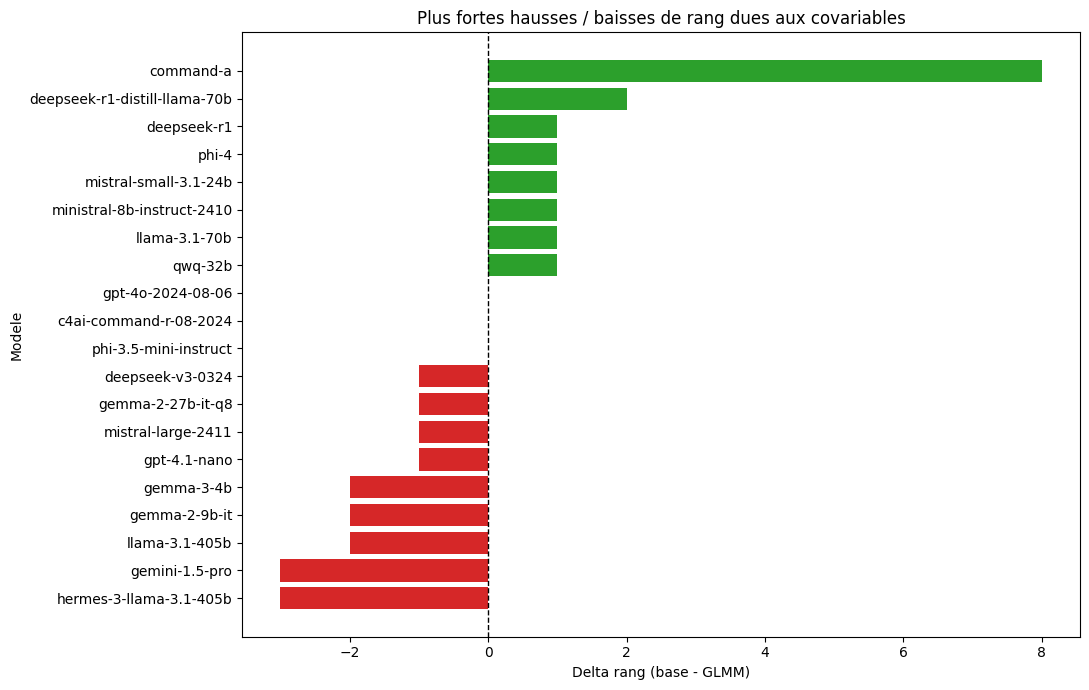

In [22]:
import matplotlib.pyplot as plt

k = 10
up = out.sort_values("delta_rank_glmm_minus_base", ascending=False).head(k)
down = out.sort_values("delta_rank_glmm_minus_base", ascending=True).head(k)
plot_df = pd.concat([down, up]).sort_values("delta_rank_glmm_minus_base")

colors = ["#d62728" if v < 0 else "#2ca02c" for v in plot_df["delta_rank_glmm_minus_base"]]

plt.figure(figsize=(11, 7))
plt.barh(plot_df.index, plot_df["delta_rank_glmm_minus_base"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Delta rang (base - GLMM)")
plt.ylabel("Modele")
plt.title("Plus fortes hausses / baisses de rang dues aux covariables")
plt.tight_layout()
plt.show()